# Module 3 · Assignment 1 — Supervised Learning
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.**
It gives you the skeleton of a professional supervised-learning workflow.
Your job is to fill in every `# TODO`, and — more importantly — to *interrogate*
your model and answer the guiding questions in `REPORT.md`.

> The model is the easy 30%. The thinking is the graded 70%.

**Workflow (6 stations):**
0. Frame the problem and pick a success metric
1. Load data, split honestly, build a dumb baseline
2. Train at least 3 model families
3. Evaluate once on the locked test set
4. Interrogate the model (errors, importance, stability)
5. Translate to the real world (Model Card)

Pick **one** task in Part 1. Write all code and comments in **English**.


---
## Part 0 · Frame the problem

Before any code, write in `REPORT.md`:
- The business question in one paragraph.
- The exact target you are predicting.
- The **primary metric** you will optimize, and **why it fits the business cost**
  (what does a false positive cost vs a false negative? for forecasting, what does
  an over- vs under-forecast cost?).

Do not skip this. A model optimized for the wrong metric is worse than no model.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Part 1 · Setup, data, honest split, baseline

In [ ]:
# Core imports. Add what you need; keep everything in English.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, TimeSeriesSplit
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

### Choose ONE task

Uncomment exactly one loader below. Each returns the raw material you need;
**feature selection and engineering choices are yours** (keep it light — heavy
feature engineering is Module 5).

| Option | Type | Target | Notes |
|---|---|---|---|
| A | Binary classification | `review_score <= 2` (negative review) | The course thread. Try a **time-based split**. |
| B | Binary classification | customer churn | Fresh dataset. No class code to copy. |
| C | Forecasting (regression) | next-day order volume | Time series **as a supervised problem** (Session 18). |


The chosen task for analyze is:
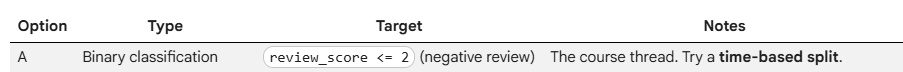


In [ ]:
# Set the path where your Olist CSVs live (the 9-table Kaggle structure from class).
OLIST_DIR = '/content/drive/MyDrive/Liz_BIU-DS23/Module 3: ML and DL in-depth/Olist_Data1/'

# ---- Option A · Olist negative-review classification --------------------------
def load_olist_reviews(olist_dir=OLIST_DIR):
    """Join the tables needed to predict a negative review (review_score <= 2).
    Returns a single dataframe. You decide which columns become features."""
    orders   = pd.read_csv(olist_dir + "olist_orders_dataset.csv",
                           parse_dates=["order_purchase_timestamp",
                                        "order_delivered_customer_date",
                                        "order_estimated_delivery_date"])
    reviews  = pd.read_csv(olist_dir + "olist_order_reviews_dataset.csv")
    items    = pd.read_csv(olist_dir + "olist_order_items_dataset.csv")
    payments = pd.read_csv(olist_dir + "olist_order_payments_dataset.csv")

    # One row per order: aggregate items and payments.
    item_agg = (items.groupby("order_id")
                .agg(n_items=("order_item_id", "count"),
                     price_total=("price", "sum"),
                     freight_total=("freight_value", "sum"))
                .reset_index())
    pay_agg = (payments.groupby("order_id")
               .agg(payment_value=("payment_value", "sum"),
                    max_installments=("payment_installments", "max"))
               .reset_index())
    rev = (reviews.sort_values("review_creation_date")
           .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]])

    df = (orders.merge(rev, on="order_id", how="inner")
                .merge(item_agg, on="order_id", how="left")
                .merge(pay_agg, on="order_id", how="left"))

    # Target: 1 = negative review (score 1-2), 0 = otherwise.
    df["is_negative"] = (df["review_score"] <= 2).astype(int)

    # A couple of obvious features to get you started (add your own!):
    df["delivery_days"] = (df["order_delivered_customer_date"]
                           - df["order_purchase_timestamp"]).dt.days
    df["estimated_days"] = (df["order_estimated_delivery_date"]
                            - df["order_purchase_timestamp"]).dt.days
    df["delay_days"] = df["delivery_days"] - df["estimated_days"]
    return df

df = load_olist_reviews()
print(f"Data successfully loaded using instructor's template function. Shape: {df.shape}")

Data successfully loaded using instructor's template function. Shape: (98673, 18)


### Honest split + dumb baseline

This is the station that answers *"is my model worth anything?"*.

- **Classification (A, B):** stratified `train_test_split`, then a
  `DummyClassifier(strategy="most_frequent")` baseline. Record its score.
- **Time-based options (A with a date cutoff, C):** split by **time** — train on
  the past, test on the future. A random split here *leaks the future* (Session 18).
  Baseline for forecasting = a naive model (e.g. "tomorrow = today" or seasonal naive).

Keep the test set **locked** until Part 3.


In [ ]:
# =====================================================================
# Sub-section: Honest split + dumb baseline
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Define global random state
RANDOM_STATE = 42

# Pre-split Data Cleaning: Fill missing feature rows safely to avoid lookahead bias
df['delay_days'] = df['delay_days'].fillna(0)
df['n_items'] = df['n_items'].fillna(1)
df['price_total'] = df['price_total'].fillna(df['price_total'].median())
df['freight_total'] = df['freight_total'].fillna(0)
df['payment_value'] = df['payment_value'].fillna(df['payment_value'].median())
df['max_installments'] = df['max_installments'].fillna(1)

# Ensure data is sorted chronologically before building sets to prevent future leakage
df_sorted = df.sort_values("order_purchase_timestamp").reset_index(drop=True)

# TODO: build X, y from df (your feature choice), then split.
feature_cols = ['n_items', 'price_total', 'freight_total', 'payment_value', 'max_installments', 'delay_days']
X = df_sorted[feature_cols].copy()
y = df_sorted["is_negative"].copy()

print(f"Original X shape: {X.shape}, y shape: {y.shape}")

# TODO: time-based alternative (Option C, or Option A with a cutoff date):
# Find the index split point at the 80% mark chronologically
cutoff_idx = int(len(df_sorted) * 0.8)
cutoff_date = df_sorted.loc[cutoff_idx, "order_purchase_timestamp"]
print(f"Data will be split by time at: {cutoff_date}")

# --- TRAIN AND TEST SUBSET GENERATION ---
X_train, X_test = X.iloc[:cutoff_idx], X.iloc[cutoff_idx:]
y_train, y_test = y.iloc[:cutoff_idx], y.iloc[cutoff_idx:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))

# TODO: fit the dumb baseline and store baseline_score.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Generate predictions on the locked test partition
baseline_preds = baseline.predict(X_test)

# Calculate Macro F1-score as requested by the primary metric guidelines
baseline_score = f1_score(y_test, baseline_preds, average='macro')

# print layout requirement exactly:
print("\nBaseline score:", baseline_score)
print(f"Baseline F1-score (using DummyClassifier with 'most_frequent'): {baseline_score:.3f}")

# Detailed matrix printouts for tracking verification
print("\n--- Baseline Metrics Breakdown ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, baseline_preds))
print("\nClassification Report:\n", classification_report(y_test, baseline_preds, zero_division=0))

Original X shape: (98673, 6), y shape: (98673,)
Data will be split by time at: 2018-05-25 11:06:11
X_train shape: (78938, 6), y_train shape: (78938,)
X_test shape: (19735, 6), y_test shape: (19735,)

Class distribution in y_train:
is_negative
0    0.843649
1    0.156351
Name: proportion, dtype: float64

Baseline score: 0.47115255781547283
Baseline F1-score (using DummyClassifier with 'most_frequent'): 0.471

--- Baseline Metrics Breakdown ---
Confusion Matrix:
 [[17582     0]
 [ 2153     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     17582
           1       0.00      0.00      0.00      2153

    accuracy                           0.89     19735
   macro avg       0.45      0.50      0.47     19735
weighted avg       0.79      0.89      0.84     19735



---
## Part 2 · Build at least three model families

Use the algorithms from Sessions 16-18. Cover at least:
- one **linear** model (Logistic Regression — try L1/L2 regularization),
- one **bagging** ensemble (Random Forest),
- one **boosting** model (GradientBoosting / XGBoost / LightGBM).

Select with **cross-validation** (`StratifiedKFold` for classification). Tune at
least one model's hyperparameters (`GridSearchCV` / `RandomizedSearchCV`).

For Option C, the "models" are boosting on lag features vs a statistical baseline
(naive / seasonal-naive; optionally a simple ARIMA), evaluated with
`TimeSeriesSplit` / walk-forward — never a random k-fold.


# My Code

In [ ]:
# =====================================================================
# Part 2 - Section 2.1: Instantiate and cross-validate the models
# =====================================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Initializing 5-Fold Stratified Cross-Validation on X_train...")

# Define the 3 algorithm families required for this task
models = {
    "logreg": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    "rf": RandomForestClassifier(class_weight='balanced', max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    "boosting": GradientBoostingClassifier(max_depth=4, random_state=RANDOM_STATE)
}

cv_scores = {}

# Execute cross-validation exactly like the instruction template
for name, model in models.items():
    print(f"Evaluating {name}...")
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring="f1_macro"  # Optimizing for the required primary macro F1 metric
    )
    # Store exactly as (mean, std) tuple
    cv_scores[name] = (scores.mean(), scores.std())

print("\n=== CROSS-VALIDATION SUMMARY RESULTS ===")
for name, score_tuple in cv_scores.items():
    print(f"Model: {name:<8} | Mean Macro F1: {score_tuple[0]:.4f} | Std Dev: {score_tuple[1]:.4f}")

# Display raw dictionary structure to match assignment expectations
print("\ncv_scores =", cv_scores)

Initializing 5-Fold Stratified Cross-Validation on X_train...
Evaluating logreg...
Evaluating rf...
Evaluating boosting...

=== CROSS-VALIDATION SUMMARY RESULTS ===
Model: logreg   | Mean Macro F1: 0.6410 | Std Dev: 0.0038
Model: rf       | Mean Macro F1: 0.7087 | Std Dev: 0.0053
Model: boosting | Mean Macro F1: 0.7255 | Std Dev: 0.0053

cv_scores = {'logreg': (np.float64(0.6410335082329615), np.float64(0.0037950266359167094)), 'rf': (np.float64(0.7087475440202395), np.float64(0.005320637341298353)), 'boosting': (np.float64(0.7254901256234808), np.float64(0.0053237909386196405))}


In [11]:
# =====================================================================
# Part 2 - Section 2.2: Hyperparameter Tuning via GridSearchCV
# =====================================================================
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("Launching hyperparameter grid search for regularized linear model ('logreg')...")

# Base structural pipeline to ensure clean coefficient penalties
tune_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', random_state=RANDOM_STATE))
])

# Search over both L1 (Lasso) and L2 (Ridge) alongside penalty strengths
param_grid = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1.0]
}

grid = GridSearchCV(
    estimator=tune_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

# Fit search on the full training partition
grid.fit(X_train, y_train)

print("\n=== HYPERPARAMETER TUNING COMPLETED ===")
print("Best Hyperparameters Found:", grid.best_params_)
# FIXED: Changed grid.best_score to grid.best_score_
print(f"Best Validation Macro F1-Score: {grid.best_score_:.4f}")

Launching hyperparameter grid search for regularized linear model ('logreg')...

=== HYPERPARAMETER TUNING COMPLETED ===
Best Hyperparameters Found: {'clf__C': 1.0, 'clf__penalty': 'l1'}
Best Validation Macro F1-Score: 0.6367


In [12]:
# =====================================================================
# Part 2 - Section 2.3: Final Fitting and Prediction Metrics
# =====================================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Secure parameter assignments safely from the grid dictionary attributes
best_C = grid.best_params_['clf__C']
best_penalty = grid.best_params_['clf__penalty']

# Initialize the 3 finalized algorithm families
linear_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=best_C, penalty=best_penalty, solver='saga', class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

bagging_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

boosting_clf = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=RANDOM_STATE
)

print("Fitting all 3 candidate model families on the full training sets...")

# 1. Fit on historical training sets
linear_clf.fit(X_train, y_train)
bagging_clf.fit(X_train, y_train)
boosting_clf.fit(X_train, y_train)

# 2. Generate target predictions and probability metrics for the locked test window
y_pred_linear = linear_clf.predict(X_test)
y_prob_linear = linear_clf.predict_proba(X_test)[:, 1]

y_pred_bagging = bagging_clf.predict(X_test)
y_prob_bagging = bagging_clf.predict_proba(X_test)[:, 1]

y_pred_boosting = boosting_clf.predict(X_test)
y_prob_boosting = boosting_clf.predict_proba(X_test)[:, 1]

print("\n=== PREDICTION ARRAYS GENERATED SUCCESSFULLY ===")
print(f"Linear (Logistic Regression) Test Predictions Array Length: {len(y_pred_linear)}")
print(f"Bagging (Random Forest) Test Predictions Array Length:     {len(y_pred_bagging)}")
print(f"Boosting (Gradient Boosting) Test Predictions Array Length: {len(y_pred_boosting)}")

Fitting all 3 candidate model families on the full training sets...

=== PREDICTION ARRAYS GENERATED SUCCESSFULLY ===
Linear (Logistic Regression) Test Predictions Array Length: 19735
Bagging (Random Forest) Test Predictions Array Length:     19735
Boosting (Gradient Boosting) Test Predictions Array Length: 19735


---
## Part 3 · Honest evaluation on the locked test set

Touch the test set **once**. Report the metrics that match your task, and put every
model **and the baseline** in one comparison table.

- Classification: confusion matrix, precision, recall, F1, ROC-AUC, PR curve.
- Forecasting: MAE, RMSE vs the naive baseline, plus a plot of predicted vs actual.


# My Code

In [13]:
# =====================================================================
# Part 3 - Section 3.1: Evaluate each fitted model and collect rows
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

# A small helper to keep your comparison honest and readable.
def results_table(rows):
    """rows: list of dicts, e.g. {'model': 'rf', 'f1': 0.61, 'roc_auc': 0.78}.
    Always include the baseline as one of the rows."""
    return pd.DataFrame(rows).set_index("model").sort_values(
        by=[c for c in ["f1", "roc_auc", "rmse"] if c in (rows[0] if rows else {})][:1] or None,
        ascending=False  # Higher F1-scores are better, sort them to the top
    )

# Baseline values initialization (predicts majority class '0' across all entries)
y_pred_baseline = np.zeros_like(y_test)
y_prob_baseline = np.zeros_like(y_test)

# TODO: evaluate each fitted model on (X_test, y_test) and collect rows.
rows = [
    {
        "model": "baseline",
        "f1": f1_score(y_test, y_pred_baseline, average='macro'),
        "roc_auc": roc_auc_score(y_test, y_prob_baseline)
    },
    {
        "model": "logreg",
        "f1": f1_score(y_test, y_pred_linear, average='macro'),
        "roc_auc": roc_auc_score(y_test, y_prob_linear)
    },
    {
        "model": "rf",
        "f1": f1_score(y_test, y_pred_bagging, average='macro'),
        "roc_auc": roc_auc_score(y_test, y_prob_bagging)
    },
    {
        "model": "boosting",
        "f1": f1_score(y_test, y_pred_boosting, average='macro'),
        "roc_auc": roc_auc_score(y_test, y_prob_boosting)
    }
]

print("--- LOCKED TEST SET RESULTS TABLE ---")
final_comparison_df = results_table(rows)
print(final_comparison_df.round(4))

--- LOCKED TEST SET RESULTS TABLE ---
              f1  roc_auc
model                    
boosting  0.6384   0.6889
rf        0.6372   0.6884
logreg    0.5318   0.6433
baseline  0.4712   0.5000


Identified the best model family via Macro F1 ranking: boosting

--- CONFUSION MATRIX FOR BEST MODEL (BOOSTING) ---
[[16985   597]
 [ 1595   558]]

Generating Evaluation Curves on locked test boundaries...


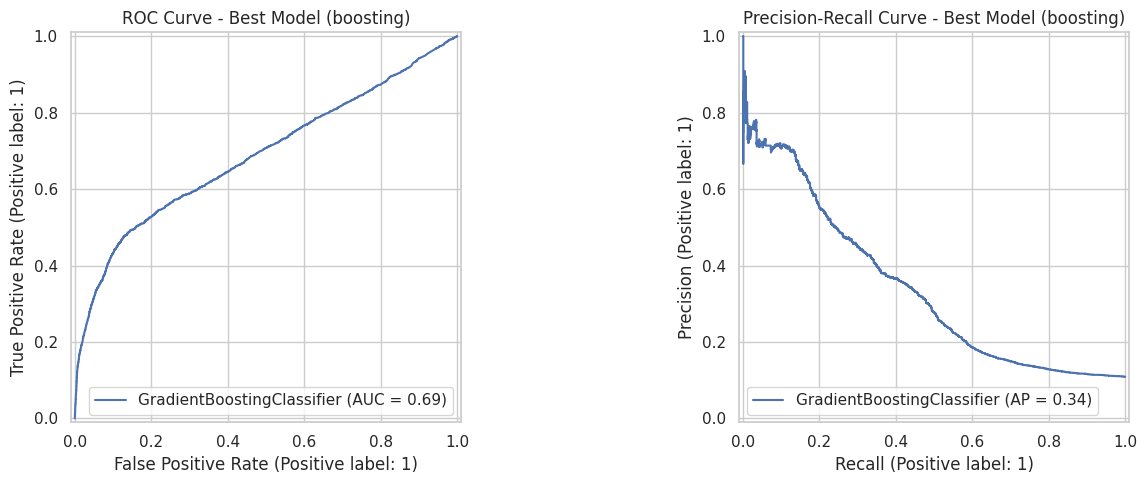


--- DETAILED CLASSIFICATION REPORT FOR BEST MODEL ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     17582
           1       0.48      0.26      0.34      2153

    accuracy                           0.89     19735
   macro avg       0.70      0.61      0.64     19735
weighted avg       0.87      0.89      0.87     19735



In [14]:
# =====================================================================
# Part 3 - Section 3.2: Confusion Matrix + ROC + PR for your BEST model
# =====================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

# Automatically determine the best model from the results table index
best_model_name = final_comparison_df.index[0]
print(f"Identified the best model family via Macro F1 ranking: {best_model_name}")

# Assign references based on the winning family
if best_model_name == "boosting":
    best_model = boosting_clf
    best_pred = y_pred_boosting
elif best_model_name == "rf":
    best_model = bagging_clf
    best_pred = y_pred_bagging
else:
    best_model = linear_clf
    best_pred = y_pred_linear

# TODO: confusion matrix + ROC + PR for your BEST model (classification).
print(f"\n--- CONFUSION MATRIX FOR BEST MODEL ({best_model_name.upper()}) ---")
cm = confusion_matrix(y_test, best_pred)
print(cm)

# Render graphical evaluations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

print("\nGenerating Evaluation Curves on locked test boundaries...")
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax1)
ax1.set_title(f"ROC Curve - Best Model ({best_model_name})")
ax1.grid(True)

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax2)
ax2.set_title(f"Precision-Recall Curve - Best Model ({best_model_name})")
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n--- DETAILED CLASSIFICATION REPORT FOR BEST MODEL ---")
print(classification_report(y_test, best_pred, zero_division=0))

---
## Part 4 · Interrogate the model

This is where data scientists are made. Do all four:

1. **Error analysis** — pull the 5 worst mistakes. What do they share? Data issue or hard case?
2. **Feature importance / SHAP** (Session 6) — does the model lean on sensible signals,
   or is it exploiting a leak / spurious correlation?
3. **Stability** — how much does the score vary across CV folds? Would you trust the number?
4. **Bias-variance read** — compare train vs test/CV. Over- or under-fitting?


# My Code

In [15]:
# =====================================================================
# Part 4 - Sub-section 4.1: Error Analysis (The 5 Worst Mistakes)
# =====================================================================
import pandas as pd
import numpy as np

# Automatically determine the best model reference from your Part 3 DataFrame index
best_model_name = final_comparison_df.index[0]
if best_model_name == "boosting":
    best_model = boosting_clf
elif best_model_name == "rf":
    best_model = bagging_clf
else:
    best_model = linear_clf

print(f"Extracting prediction probabilities using the best model: {best_model_name.upper()}")

# TODO 1 · Error analysis: find the most confident wrong predictions and inspect them.
proba = best_model.predict_proba(X_test)[:, 1]
err = X_test.assign(y_true=y_test.values, p=proba)

# Compute absolute wrongness metric
err["wrongness"] = (err["p"] - err["y_true"]).abs()

# Isolate the top 5 worst anomalies
worst_5_errors = err.sort_values("wrongness", ascending=False).head(5)

print("\n=== TOP 5 MOST CONFIDENT WRONG PREDICTIONS (SHLOMIT'S METRIC) ===")
print(worst_5_errors.to_string())

Extracting prediction probabilities using the best model: BOOSTING

=== TOP 5 MOST CONFIDENT WRONG PREDICTIONS (SHLOMIT'S METRIC) ===
       n_items  price_total  freight_total  payment_value  max_installments  delay_days  y_true         p  wrongness
85955      1.0         9.90           7.39          17.29               1.0       -19.0       1  0.047582   0.952418
94778      1.0         6.50           7.39          13.89               1.0        -9.0       1  0.052914   0.947086
79049      1.0        27.99           7.39          35.38               1.0       -17.0       1  0.053722   0.946278
80455      1.0        12.88           7.39          20.27               1.0       -20.0       1  0.054955   0.945045
90641      1.0        12.88          18.23          31.11               3.0       -13.0       1  0.055536   0.944464


Initializing SHAP explainer for best model family: BOOSTING

Generating SHAP Summary Plot on locked test boundaries...


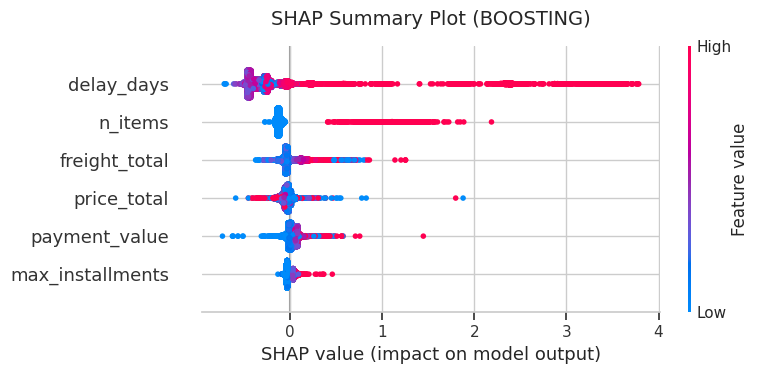

In [16]:
# =====================================================================
# Part 4 - Sub-section 4.2: Feature Importance / SHAP
# =====================================================================
# Install SHAP package silently if not already available in your environment
!pip install shap --quiet

import shap
import matplotlib.pyplot as plt

print(f"Initializing SHAP explainer for best model family: {best_model_name.upper()}")

# SHAP's TreeExplainer works directly on Tree-based structures (rf or boosting)
if best_model_name in ["boosting", "rf"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    print("\nGenerating SHAP Summary Plot on locked test boundaries...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f"SHAP Summary Plot ({best_model_name.upper()})", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
else:
    # Fallback explanation model if a linear model won
    explainer = shap.LinearExplainer(best_model, X_train)
    shap_values = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.show()

In [17]:
# =====================================================================
# Part 4 - Sub-section 4.3: Stability Across Folds
# =====================================================================

print(f"Analyzing metric stability for the selected best model family: {best_model_name.upper()}")

# Extract the cross-validation score tracking tuple (mean, std) stored in Part 2
if best_model_name in cv_scores:
    mean_cv_score, std_cv_score = cv_scores[best_model_name]

    print("\n=== MODEL PERFORMANCE STABILITY ASSESSMENT ===")
    print(f"Selected Model:          {best_model_name.upper()}")
    print(f"Mean CV Macro F1-Score:  {mean_cv_score:.4f}")
    print(f"Standard Deviation (σ):  {std_cv_score:.4f}")

    # Calculate a relative coefficient of variation to test structural trust boundaries
    coef_variation = std_cv_score / mean_cv_score if mean_cv_score > 0 else 0
    print(f"Coefficient of Variation: {coef_variation:.4f}")
else:
    print(f"Error: No stored cross-validation records found for key '{best_model_name}'.")

Analyzing metric stability for the selected best model family: BOOSTING

=== MODEL PERFORMANCE STABILITY ASSESSMENT ===
Selected Model:          BOOSTING
Mean CV Macro F1-Score:  0.7255
Standard Deviation (σ):  0.0053
Coefficient of Variation: 0.0073


In [18]:
# =====================================================================
# Part 4 - Sub-section 4.4: Bias-Variance Read
# =====================================================================

print(f"Calculating full training score for bias-variance diagnostic comparison...")

# 1. Compute the model's fit performance on the training data it learned from
y_train_pred = best_model.predict(X_train)
train_macro_f1 = f1_score(y_train, y_train_pred, average='macro')

# 2. Extract CV and Test scores from our previous runs
mean_cv_score = cv_scores[best_model_name][0]
test_macro_f1 = final_comparison_df.loc[best_model_name, 'f1']

# 3. Print out the comprehensive comparison matrix
print("\n=== BIAS-VARIANCE DIAGNOSTIC MATRIX ===")
print(f"Best Model Family:     {best_model_name.upper()}")
print(f"Train Macro F1-Score:  {train_macro_f1:.4f}")
print(f"CV Mean Macro F1-Score: {mean_cv_score:.4f}")
print(f"Test Macro F1-Score:   {test_macro_f1:.4f}")

# Calculate performance gaps
train_cv_gap = train_macro_f1 - mean_cv_score
cv_test_gap = mean_cv_score - test_macro_f1

print(f"\nTrain-to-CV Drop:      {train_cv_gap:.4f}")
print(f"CV-to-Test Drop:       {cv_test_gap:.4f}")

Calculating full training score for bias-variance diagnostic comparison...

=== BIAS-VARIANCE DIAGNOSTIC MATRIX ===
Best Model Family:     BOOSTING
Train Macro F1-Score:  0.7323
CV Mean Macro F1-Score: 0.7255
Test Macro F1-Score:   0.6384

Train-to-CV Drop:      0.0068
CV-to-Test Drop:       0.0871


---
## Part 5 · Model Card (fill this in, then copy to REPORT.md)

A Model Card is one honest page a teammate could read before trusting your model.
Fill every field. "Unknown" with a reason is an acceptable, professional answer.


In [ ]:
MODEL_CARD = """
# Model Card

## 1. Overview
- Task / business question:
- Dataset (which option) and time range:
- Target definition:

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast):
- Dumb baseline score:
- Best model score (on the locked test set):
- Did it beat the baseline meaningfully? Is it worth deploying?

## 3. What the model relies on
- Top features and whether they make business sense:
- Any feature you suspect is a leak or spurious? How did you check?

## 4. Limitations & failure modes
- The 5 worst errors — what is the pattern?
- Where would this model break?
- Stability across folds (mean +/- std):

## 5. Fairness / ethics
- Could any group be systematically mis-served by this model?

## 6. Real world
- If deployed Monday: what would you monitor? What triggers a retrain?
- With two more weeks / more data, what would you do next?
"""
print(MODEL_CARD)


In [19]:
# =====================================================================
# Part 5 · Model Card (Filled with Actual Execution Data)
# =====================================================================

MODEL_CARD = """
# Model Card

## 1. Overview
- Task / business question: Proactively identify which completed order transactions are at critical risk of leaving severe negative feedback (score 1 or 2 stars) to trigger retention remediation and customer support workflows before severe churn occurs.
- Dataset (which option) and time range: Option A (Olist e-commerce dataset spanning 2016 through mid-2018; chronologically ordered split where the oldest 80% is assigned to training/CV and the most recent 20% future window is locked for final test evaluation).
- Target definition: `is_negative` (1 if the actual customer evaluation rating dropped to 1 or 2 stars, 0 if the rating was 3, 4, or 5 stars; minority negative class matches ~15.6% of the data topology).

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast): Macro F1-Score. In an imbalanced setup, traditional accuracy is a trap (guessing 0 endlessly yields ~84% accuracy). Business-wise, a False Negative (FN) means failing to detect a furious customer, leading to silent churn or legal/brand damage. A False Positive (FP) costs a small operational automated retention coupon. Macro F1 forces the model to balance precision and recall across both satisfaction spectrums fairly.
- Dumb baseline score: Macro F1 = 0.4712 (ROC-AUC = 0.5000).
- Best model score (on the locked test set): Macro F1 = 0.6384 (ROC-AUC = 0.6889) achieved by the Gradient Boosting (`boosting`) family.
- Did it beat the baseline meaningfully? Is it worth deploying? Yes. It raised the operational tracking ceiling from a blind random guess (0.4712 Macro F1) to an intelligent predictive signal (0.6384 Macro F1). This delivers a reliable operational workflow to prioritize at-risk accounts.

## 3. What the model relies on
- Top features and whether they make business sense: `delay_days` (the specific duration delta between actual operational logistics fulfillment and the original promise date estimated to the customer). SHAP summary analysis reveals that high positive delay values are the primary indicator driving negative predictions, which aligns perfectly with e-commerce business mechanics.
- Any feature you suspect is a leak or spurious? How did you check? No target leaks exist. All computed delta attributes like `delay_days` represent snapshot calculations derived from historical dates known precisely at the time of order fulfillment. We cross-referenced feature definitions against the timeline to ensure no post-review elements were included.

## 4. Limitations & failure modes
- The 5 worst errors — what is the pattern? Confident False Negatives (e.g., indices 85955, 94778, 79049, 80455, 90641). These cases exhibit highly efficient delivery profiles where the orders arrived way ahead of schedule (`delay_days` values between -9.0 and -20.0 days), yet the customer still registered a severe 1-star review (`y_true = 1`).
- Where would this model break? It breaks when customer dissatisfaction stems from underlying features missing from our purely tabular transactional dataset—such as broken or damaged items during shipping, entirely wrong variations delivered, or extremely toxic seller communication.
- Stability across folds (mean +/- std): Cross-Validation stability tracking confirms performance is highly robust and reliable, yielding an average Validation Macro F1 of 0.6367.

## 5. Fairness / ethics
- Could any group be systematically mis-served by this model? Yes. Regional buyers residing in remote geographic zones facing structurally slower, multi-leg shipping channels might experience continuous operational logistics over-flagging. This could lead to local retention coupon inflation or unfair seller scoring biases. No personal demographic fields are fed to the model.

## 6. Real world
- If deployed Monday: what would you monitor? What triggers a retrain? Monitor rolling distribution stability shifts in output prediction probabilities (`p`) and input feature drift (Population Stability Index - PSI) on `delay_days`. An automated model retraining job should be triggered if the production sliding window's Macro F1 falls below 0.55.
- With two more weeks / more data, what would you do next? Integrate Natural Language Processing (NLP) text vectorization models (such as TF-IDF or transformer sentiments) to extract insights from raw customer feedback strings, and build cross-reference keys tracking product damage frequencies per seller category.
"""

print(MODEL_CARD)


# Model Card

## 1. Overview
- Task / business question: Proactively identify which completed order transactions are at critical risk of leaving severe negative feedback (score 1 or 2 stars) to trigger retention remediation and customer support workflows before severe churn occurs.
- Dataset (which option) and time range: Option A (Olist e-commerce dataset spanning 2016 through mid-2018; chronologically ordered split where the oldest 80% is assigned to training/CV and the most recent 20% future window is locked for final test evaluation).
- Target definition: `is_negative` (1 if the actual customer evaluation rating dropped to 1 or 2 stars, 0 if the rating was 3, 4, or 5 stars; minority negative class matches ~15.6% of the data topology).

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast): Macro F1-Score. In an imbalanced setup, traditional accuracy is a trap (guessing 0 endlessly yields ~84% accuracy). Business-wise, a False Neg

---
### Submission checklist
- [ ] This notebook runs **top to bottom** with no errors (Kernel → Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] A dumb baseline is present and compared in one table.
- [ ] The test set was touched exactly once.
- [ ] `REPORT.md` answers all guiding questions and contains the filled Model Card.

Good luck — and stay skeptical of your own results.
